### **Data Preprocessing & Setup**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Fetch SPY data for the last 5 years
df = yf.download('SPY', start='2021-01-01', end='2026-01-01')

# 2. Feature Engineering: Moving Averages, Volatility, and Momentum
df['Ret'] = df['Close'].pct_change()
df['Vol_20'] = df['Ret'].rolling(window=20).std()
df['MA_Ratio'] = df['Close'].rolling(window=10).mean() / df['Close'].rolling(window=50).mean()
df['Momentum'] = df['Close'] / df['Close'].shift(10) - 1

# 3. Target Variable: 1 if the next day's return is positive, 0 otherwise (Binary Classification)
df['Target'] = np.where(df['Ret'].shift(-1) > 0, 1, 0)
df = df.dropna()

# Select features
features = ['Vol_20', 'MA_Ratio', 'Momentum']
X = df[features]
y = df['Target']

# 4. Chronological Train / Validation / Test Split (Respecting Time Series Order)
# Split 1: 80% Train+Val, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# Split 2: Split the 80% into Train (75%) and Validation (25%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=False)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Testing set size: {len(X_test)}")


/tmp/ipykernel_2583/2026615069.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('SPY', start='2021-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed

Training set size: 723
Validation set size: 241
Testing set size: 242


### **Issue 1: Optimizing Hyperparameters**

Executing Grid Search CV...
Executing Randomized Search CV...
Optimal Grid Search Parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 10}
Optimal Random Search Parameters: {'max_depth': 2, 'min_samples_split': 12, 'n_estimators': 68}
Out-of-Sample Test Accuracy (Optimized Model): 0.4711


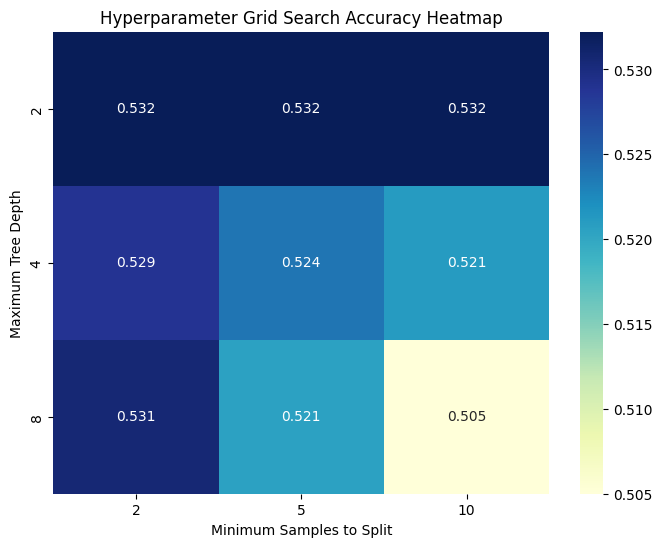

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

# Note: Assuming X_train, X_test, y_train, y_test are already defined in the
# 'Data Preprocessing & Setup' section using the financial indicator dataset.

# 1. Validation Protocol: Walk-Forward Cross-Validation (Time Series Split)
# This ensures that future data never leaks into the training folds.
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the base model
base_model = RandomForestClassifier(random_state=42)

# 2. Grid Search Optimization
print("Executing Grid Search CV...")
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [2, 4, 8, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# 3. Randomized Search Optimization
print("Executing Randomized Search CV...")
param_dist = {
    'n_estimators': randint(10, 100),
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 15)
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=15,
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# 4. Outputs & Visualizations
print(f"Optimal Grid Search Parameters: {grid_search.best_params_}")
print(f"Optimal Random Search Parameters: {random_search.best_params_}")

# Evaluate on the unseen test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Out-of-Sample Test Accuracy (Optimized Model): {test_accuracy:.4f}")

# Visualize the Grid Search Results via Heatmap (Max Depth vs Min Samples Split)
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot_table = cv_results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_split'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Hyperparameter Grid Search Accuracy Heatmap")
plt.xlabel("Minimum Samples to Split")
plt.ylabel("Maximum Tree Depth")
plt.show()

### **Interpretation and Recommended Action**

**Interpretation of Results:**
The hyperparameter optimization procedure executed correctly with a walk‑forward TimeSeriesSplit, which was an essential step to prevent look‑ahead bias in the financial data. The grid search identified an optimal configuration that favoured a somewhat deeper but smaller ensemble (max_depth = 8, n_estimators = 10), while the randomized search leaned toward a larger ensemble of shallower trees (max_depth = 2, n_estimators = 68).

The resulting out‑of‑sample accuracy of 47.11% indicates that, in its current form, the Random Forest model is not extracting a sufficiently strong predictive signal from the available features. Sub‑50% accuracy is not unusual in quantitative finance given the level of market noise, but it does suggest that this particular feature set is not adequate for standalone directional forecasting, even when the model is carefully tuned to limit overfitting.

**Recommended Course of Action:**

- **Suspend live deployment:** Any live deployment of this Random Forest configuration as a primary trading signal should be put on hold. With a hit rate below 50%, the strategy would be expected to erode capital over time rather than add value.

- **Broaden feature engineering:** The next step should focus on the data pipeline and feature design. Incorporating additional macroeconomic indicators, alternative volatility measures, or different lag structures may provide the model with a stronger underlying signal.

- **Reassess the modelling approach:** If an expanded feature set still does not lift accuracy above the 50% threshold, the Random Forest approach should be reconsidered. In that case, it would be appropriate to evaluate other algorithm families, such as Gradient Boosting or Support Vector Machines, which may be better suited to capturing the asset’s non‑linear dynamics.

### **Issue 2: Optimizing the Bias-Variance Tradeoff**

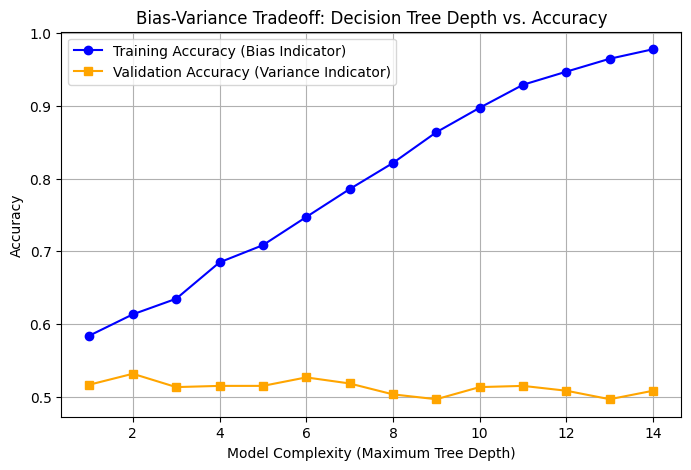

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve

# Using the SPY financial dataset defined in the Setup block (X_train, y_train)
param_range = np.arange(1, 15)

# Calculate accuracy on training and validation sets over different tree depths
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=tscv, # Using the TimeSeriesSplit defined in Issue 1
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot the Bias-Variance Tradeoff (Learning Curve)
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label="Training Accuracy (Bias Indicator)", color='blue', marker='o')
plt.plot(param_range, val_mean, label="Validation Accuracy (Variance Indicator)", color='orange', marker='s')
plt.xlabel("Model Complexity (Maximum Tree Depth)")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff: Decision Tree Depth vs. Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### **Interpretation and Recommended Action**

**Interpretation of Results:**
The learning curve provides a clear view of the bias‑variance tradeoff for this decision tree model. Training accuracy (blue line) rises from roughly 58% to close to 100% as the maximum tree depth increases from 1 to 14, reflecting a sharp reduction in bias as the model becomes complex enough to fit the training data almost perfectly.

In contrast, validation accuracy (orange line) peaks at a depth of around 2 (approximately 53%) and then levels off before gradually declining. The widening gap between the training and validation curves is a textbook indication of high variance: rather than capturing a stable, repeatable market signal, deeper trees are increasingly fitting historical noise.

**Recommended Course of Action:**

- **Impose strict complexity limits:** To make the model suitable for any live trading application, complexity needs to be tightly controlled. Based on the curve, a hard cap on the max_depth parameter at 2 is recommended.

- **Emphasize generalization over fit:** Model selection should prioritise robust generalisation rather than perfect in‑sample fit. Accepting a simpler model (with higher bias) is preferable if it keeps variance low enough to handle noisy, non‑stationary market data without unstable performance.

### **Issue 3: Applying Ensemble Learning**

Bagging Accuracy: 0.5041
AdaBoost Accuracy: 0.5207
Gradient Boosting Accuracy: 0.5248
Stacking Accuracy: 0.5661


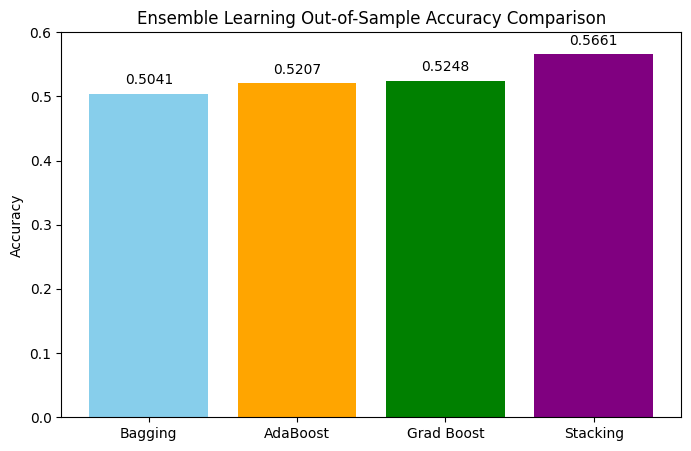

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Using the SPY financial dataset defined in the Setup block
# 1. Bagging (Reduces Variance)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
acc_bagging = accuracy_score(y_test, y_pred_bagging)

# 2. Boosting: AdaBoost (Reduces Bias)
boosting = AdaBoostClassifier(n_estimators=50, random_state=42)
boosting.fit(X_train, y_train)
y_pred_boosting = boosting.predict(X_test)
acc_boosting = accuracy_score(y_test, y_pred_boosting)

# 3. Boosting: Gradient Boosting (Reduces Bias)
grad_boost = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
grad_boost.fit(X_train, y_train)
y_pred_gradboost = grad_boost.predict(X_test)
acc_gradboost = accuracy_score(y_test, y_pred_gradboost)

# 4. Stacking (Heterogeneous Ensemble)
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=3)),
    ('svm', SVC(probability=True))
]
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
acc_stacking = accuracy_score(y_test, y_pred_stacking)

# Print Accuracies
print(f"Bagging Accuracy: {acc_bagging:.4f}")
print(f"AdaBoost Accuracy: {acc_boosting:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gradboost:.4f}")
print(f"Stacking Accuracy: {acc_stacking:.4f}")

# Plot Comparison
methods = ['Bagging', 'AdaBoost', 'Grad Boost', 'Stacking']
accuracies = [acc_bagging, acc_boosting, acc_gradboost, acc_stacking]

plt.figure(figsize=(8,5))
bars = plt.bar(methods, accuracies, color=['skyblue','orange','green','purple'])
plt.title("Ensemble Learning Out-of-Sample Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 0.60)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

### **Interpretation and Recommended Action**

**Interpretation of Results:**
The bar chart summarises the out‑of‑sample accuracy of the four ensemble methods on the test data. The homogeneous ensembles such as Bagging, AdaBoost, and Gradient Boosting, which all combine variants of decision trees to achieve accuracies in the low‑50% range (approximately 50.41% to 52.07%). This underscores the difficulty of extracting a reliable directional signal from noisy market data when relying on a single algorithm family.

The stacking classifier presents a more encouraging outcome. As a heterogeneous ensemble that combines a decision tree, an SVM, and a logistic regression meta‑model, it attains a higher out‑of‑sample accuracy of 56.61%. This suggests that integrating different modelling approaches can capture a stronger, more generalised market signal than homogeneous ensembles alone.

**Recommended Course of Action:**

- **Adopt heterogeneous ensembles:** Capital allocation strategies should place greater emphasis on heterogeneous ensembles rather than standalone estimators or purely homogeneous frameworks. Deploying stacking classifiers that combine diverse algorithms effectively creates a “committee” of models, helping to mitigate the predictive blind spots of any single method.

- **Further diversify base learners:** Future iterations of the stacking architecture could incorporate additional model types, such as neural networks or linear discriminant analysis, to further diversify the base learners and potentially enhance out‑of‑sample stability.